# Inference Check

In [1]:
import sys
import os

os.chdir("..")

from dataset import UnlabeledDetectionDataset
from network import FRCNNDetector

Load data:

In [2]:
from pathlib import Path
import pandas as pd
from training import explore_dataset, INFERENCE_TRANSFORMS

df = explore_dataset(Path("../data_det_public/data_det_public"))
unlabeled_df = UnlabeledDetectionDataset(df, INFERENCE_TRANSFORMS)

C:\workspace\git\single-class-detection\src\DET_524839\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\workspace\git\single-class-detection\src\DET_524839\.venv\Lib\site-packages\albumentations\core\composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


Inference visualizer:

In [8]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from numpy.typing import NDArray

MEAN = [81.7474, 59.7219, 70.0178]
STD = [47.6729, 41.8091, 46.3294]

def prepare(image: torch.Tensor) -> NDArray:
    image = image.permute(1, 2, 0)
    image = image.cpu().numpy()
    image = image.copy()
    for i in range(3):
        image[:, :, i] = image[:, :, i] * STD[i] + MEAN[i]
    return image.astype(np.uint8)

@torch.no_grad()
def run_inference_and_plot(model: torch.nn.Module, image: torch.Tensor, score_thresh: float) -> None:
    model.eval()

    images = [image]
    outputs = model(images)
    print(outputs)
    outputs = outputs[0]
    boxes = outputs["boxes"].cpu()
    scores = outputs["scores"].cpu()
    labels = outputs["labels"].cpu()

    # -----------------------
    # Filter predictions
    # -----------------------
    keep = scores >= score_thresh
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    # -----------------------
    # Convert image for plotting
    # -----------------------
    img = prepare(image)
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    # -----------------------
    # Draw boxes
    # -----------------------
    for box, score, label in zip(boxes, scores, labels):
        xmin, ymin, xmax, ymax = box

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)
        ax.text(
            xmin,
            ymin,
            f"{label.item()} {score:.2f}",
            color="white",
            bbox=dict(facecolor="red", alpha=0.5)
        )

    plt.axis("off")
    plt.show()

Sample inference:

In [4]:
model = FRCNNDetector()

[{'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64), 'scores': tensor([])}]


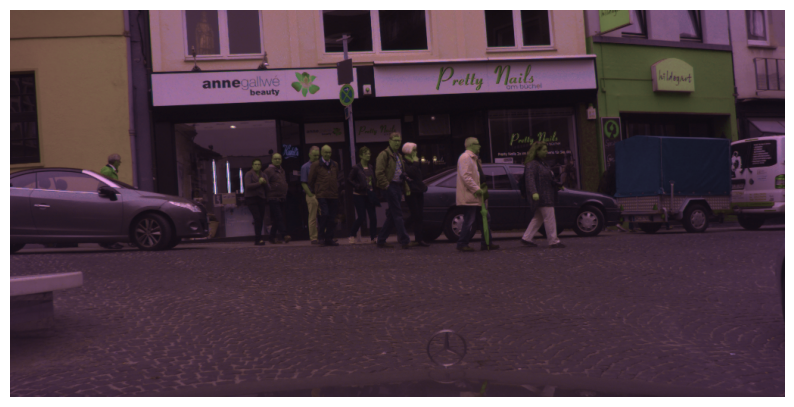

In [9]:
run_inference_and_plot(model, unlabeled_df[15][0], 0.0)